In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bitalg.tests.test3 import Test
from bitalg.visualizer.main import Visualizer

# Triangulacja wielokątów monotonicznych - problem monitorowania galerii


## Przydatne funkcje


In [2]:
polygon_example_1 = [(5,5), (3,4), (6,3), (4,2), (6,0), (7,1), (8,4)]
polygon_example_2 = [(2,0), (5,1), (6,0), (8,3), (7,2), (8,7), (6,9), (5,8), (2,9), (1,7), (2,4), (4,5), (3,6), (5, 7), (5.5, 3), (2,2), (1,3), (0,1)]
polygon_example_colors = [1, 3, 1, 0, 2, 4, 0, 2, 0, 4, 1, 4, 4, 3, 4, 2, 0, 4]
polygon_example_tri = [(polygon_example_1[0], polygon_example_1[2]),
                      (polygon_example_1[2], polygon_example_1[5]),
                      (polygon_example_1[2], polygon_example_1[6]),
                      (polygon_example_1[2], polygon_example_1[4])]

In [3]:
def draw_polygon(polygon):
    vis = Visualizer()
    vis.axis_equal()
    points = polygon
    vis.add_polygon(polygon, fill=False)
    vis.show()

In [4]:
def save_polygon(polygon, pname):
    vis = Visualizer()
    vis.axis_equal()
    points = polygon
    vis.add_polygon(polygon, fill=False)
    vis.save(os.path.join('data', f'{pname}', f'polygon_{pname}'))

In [5]:
def draw_polygon_colors(polygon, colors):
    points_start=[]
    points_end=[]
    points_connect=[]
    points_divide=[]
    points_regular=[]
    for i in range(len(polygon)):
        if colors[i]==0:
            points_start.append(polygon[i])
        elif colors[i]==1:
            points_end.append(polygon[i])
        elif colors[i]==2:
            points_connect.append(polygon[i])
        elif colors[i]==3:
            points_divide.append(polygon[i])
        elif colors[i]==4:
            points_regular.append(polygon[i])

    vis = Visualizer()
    vis.axis_equal()
    colors_start = 'green'
    color_end='red'
    color_connect='blue'
    color_divide='cyan'
    color_regular='#3B240B'
    vis.add_polygon(polygon, fill=False)
    vis.add_point(points_start, color=colors_start)
    vis.add_point(points_end, color=color_end)
    vis.add_point(points_connect, color=color_connect)
    vis.add_point(points_divide, color=color_divide)
    vis.add_point(points_regular, color=color_regular)
    vis.show()

In [6]:
def save_polygon_colors(polygon, colors, pname):
    points_start=[]
    points_end=[]
    points_connect=[]
    points_divide=[]
    points_regular=[]
    for i in range(len(polygon)):
        if colors[i]==0:
            points_start.append(polygon[i])
        elif colors[i]==1:
            points_end.append(polygon[i])
        elif colors[i]==2:
            points_connect.append(polygon[i])
        elif colors[i]==3:
            points_divide.append(polygon[i])
        elif colors[i]==4:
            points_regular.append(polygon[i])

    vis = Visualizer()
    vis.axis_equal()
    colors_start = ['green']
    color_end=['red']
    color_connect=['blue']
    color_divide=['cyan']
    color_regular=['#3B240B']
    vis.add_polygon(polygon, fill=False)
    vis.add_point(points_start, color=colors_start)
    vis.add_point(points_end, color=color_end)
    vis.add_point(points_connect, color=color_connect)
    vis.add_point(points_divide, color=color_divide)
    vis.add_point(points_regular, color=color_regular)
    vis.save(os.path.join('data', f'{pname}', f'colors_{pname}'))

In [7]:
def draw_triangulation(polygon, T):
    vis = Visualizer()
    vis.axis_equal()
    points = polygon
    T_line_segments = T
    vis.add_polygon(points, fill=False)
    vis.add_point(points)
    vis.add_line_segment(T_line_segments, color='red')
    vis.show()

In [8]:
def save_triangulation(polygon, T, pname):
    vis = Visualizer()
    vis.axis_equal()
    points = polygon
    T_line_segments = T
    vis.add_polygon(points, fill=False)
    vis.add_point(points)
    vis.add_line_segment(T_line_segments, color='red')
    vis.save(os.path.join('data', f'{pname}', f'triangulation_{pname}'))

## Wprowadzenie
Celem ćwiczenia jest:
- sprawdzanie $y$-monotoniczności
- podział wierchołków na kategorie
- triangulacja wielokąta monotonicznego

### Przykładowy wielokąt $y$-monotoniczny

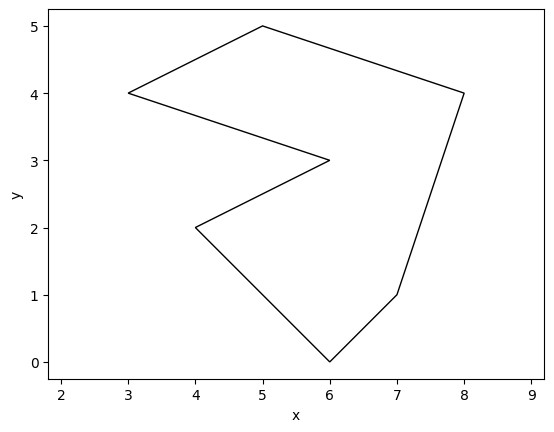

In [202]:
draw_polygon(polygon_example_1)

Do tego celu wygeneruj wielokąt.

In [203]:
funkcja generujaca wielokat, kliknięcie lewym przyciskiem myszy dodaje wierzchołek wielokata, 
z kolei prawym - kończy tworzenie wielokata

SyntaxError: invalid syntax (2450300569.py, line 1)

In [12]:
#rysowanie wielokata
%matplotlib tk
drawn_polygon = []
active = True

def draw_point(point):
    plt.scatter(point[0], point[1], color="red")
    plt.show()

def draw_line(points):
    ax = plt.gca()
    x = [points[0][0], points[1][0]]
    y = [points[0][1], points[1][1]]
    line = ax.plot(x, y, color="red") 
    ax.figure.canvas.draw()        

def onclick(event):
    global drawn_polygon, active
    
    if event.button and active:
        if event.button == 1:
            drawn_polygon.append((event.xdata, event.ydata))
            draw_point(drawn_polygon[-1])
            if len(drawn_polygon) == 1: return
            draw_line([drawn_polygon[-1], drawn_polygon[-2]])
        if event.button == 3:
            active = False
            draw_line([drawn_polygon[-1], drawn_polygon[0]])
            plt.pause(1)
            plt.close()

fig, ax = plt.subplots()
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.aspect=1
plt.tight_layout()
cid = fig.canvas.mpl_connect('button_press_event', onclick)
plt.ion()
plt.show()

[(np.float64(-0.45568583277866104), np.float64(8.26511750726168)), (np.float64(-3.9946751318416887), np.float64(0.13731185635067078)), (np.float64(-0.1607700578567428), np.float64(-8.941114338526539)), (np.float64(2.272285085249088), np.float64(0.18484288354898126))]


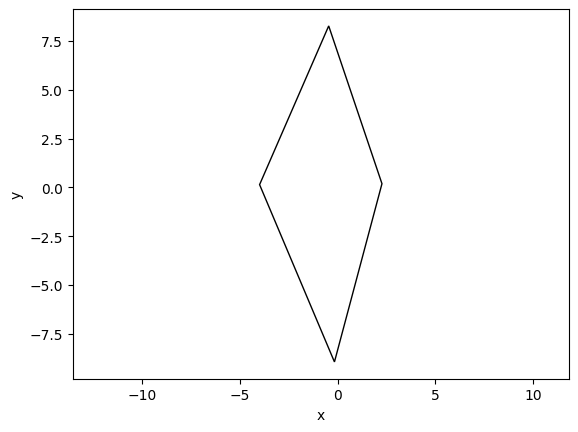

In [13]:
%matplotlib inline

if len(drawn_polygon) < 3:
    print("wielokąt musi mieć więcej niż 2 punkty")
else:
    draw_polygon(drawn_polygon)
    print(drawn_polygon)

In [9]:
#zapisuje listę wierzchołków do pliku tekstowego, jeden wiersz = jeden wierzchołek w formacie: x y
def save_vertices(vertices, filename):
    #vertices_ccw = ensure_ccw(vertices)
    with open(os.path.join('data', f'{filename}', f'vertices_{filename}'), "w") as f:
        for x, y in vertices:
            f.write(f"{x} {y}\n")


In [10]:
#wczytuje listę krotek (x, y) z pliku, gdzie każda linia ma format: x y
def load_vertices(filename):
    vertices = []
    with open(os.path.join('data', f'{filename}', f'vertices_{filename}'), "r") as f:
        for line in f:
            x, y = line.split()
            vertices.append((float(x), float(y)))
    return vertices


In [14]:
polygon = drawn_polygon
save_vertices(polygon, 'A')

In [208]:
Przydatne funkcje


SyntaxError: invalid syntax (2820613243.py, line 1)

In [15]:
#funkcja znajduje indeksy najmniejszego i największego punktu względem współrzędnej y
def get_min_max_y(polygon):
  n = len(polygon)
  index_min = index_max = 0
    
  for i in range(n):
    if polygon[index_min][1] > polygon[i][1]:
      index_min = i
    if polygon[index_max][1] < polygon[i][1]:
      index_max = i
        
  return index_min, index_max

In [16]:
#funkcja zwraca oreintacje trzech punktów
def compare(a, b, c):
    EPS = 11e-24
    
    orient = mat_det(a, b, c)
    if abs(orient) <= EPS:
        return 0
    elif orient < 0:
        return -1
    elif orient > 0:
        return 1

In [17]:
#funkcja oblicza wyznacznik 3x3
def mat_det(a, b, c):
    xa, ya = a
    xb, yb = b
    xc, yc = c

    return (xa * yb * 1 + ya * 1 * xc + 1 * xb * yc) - (1 * yb * xc + ya * xb * 1 + xa * 1 * yc)

In [18]:
#funkcja dzieli wierzchołki wielokąta monotonicznego na dwa łańcuchy
    
def partition_into_chains(polygon):
    n = len(polygon)
    min_y, max_y = get_min_max_y(polygon)
    left = []
    right = []
    direction = 1
    
    current = max_y
    is_left = True
    for _ in range(n):
        if is_left:
            left.append(polygon[current])
        else:
            right.append(polygon[current])
        if current == min_y: 
            direction = -1
            is_left = False 
            current = max_y
      
        current = (current + 1 * direction) % n
    
    return left, right

## Czy wielokąt jest $y$-monotoniczny?

Wielokąt jest monotoniczny, gdy jego wierzchołki mogą być ułożone w taki sposób, że jedna z jego współrzędnych (na przykład współrzędna $x$ lub $y$, w zależności od układu współrzędnych) zawsze rośnie lub maleje wzdłuż kolejnych wierzchołków. Innymi słowy, dla każdej pary wierzchołków wielokąta (oprócz wierzchołka startowego i końcowego), jeden z punktów ma większą (lub mniejszą) wartość danej współrzędnej niż drugi punkt.

W praktyce, wielokąt monotoniczny może być łatwiej sortowany lub przetwarzany w pewnych algorytmach geometrycznych, ponieważ istnieje pewna kolejność, w jakiej wierzchołki pojawiają się wzdłuż danej osi (np. osi $x$ lub $y$). Monotoniczność może ułatwić znajdowanie przecięć linii w takim wielokącie lub wykonywanie innych operacji geometrycznych. W tym zadaniu interesuje nas monotoniczność wielokąta wzdłuż osi $y$.

<span style="color:red">Ćw.</span> Uzupełnij funkcję ```is_y_monotonic```. Pamiętaj, aby sprawozdanie zawierało krótki opis działania tej funkcji.

In [19]:
def is_chain_monotnic(chain):
    n = len(chain)
    if n <= 2: return True
  
    for i in range(1, n):
        if chain[i - 1][1] < chain[i][1]:
            return False
    return True

In [20]:
def is_y_monotonic(polygon):
    """
    Funkcja określa czy podana figura jest y-monotoniczna.
    :param polygon: tablica krotek punktów na płaszczyźnie euklidesowej podanych przeciwnie do ruchu wskazówek zegara - nasz wielokąt
    :return: wartość bool - true, jeśli wielokąt jest monotoniczny i false jeśli nie jest
    """
    left, right = partition_into_chains(polygon)
    return is_chain_monotnic(right) and is_chain_monotnic(left)


Przeprowadź test poprawności powyższej funkcji.

In [21]:
Test().runtest(1, is_y_monotonic)

Lab 3, task 1:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
	Test 4: Passed
	Test 5: Passed
	Test 6: Passed
	Test 7: Passed
	Test 8: Passed
	Test 9: Passed
	Test 10: Passed
Result: 10/10
Time: 0.005s


In [22]:
print(is_y_monotonic(polygon))

True


Sprawdź monotoniczność swojego wielokątu.

# Podział wierzchołków na kategorie

Wierzchołki naszego wielokąta możemy podzielić na parę kategorii:
- początkowe, gdy obaj jego sąsiedzi leżą poniżej i kąt wewnętrzny ma mniej niż 180 stopni. To wierzchołki, w których zaczyna się monotoniczny spadek
- końcowe, gdy obaj jego sąsiedzi leżą powyżej i kąt wewnętrzny ma mniej niż 180 stopni. To wierzchołki, w których monotoniczność wielokąta się zmienia, czyli na przykład zaczyna się monotoniczny wzrost, jeśli wcześniej był spadek, lub na odwrót.

Wierzchołki startowe i końcowe są ważne w kontekście algorytmów przetwarzania wielokątów monotonicznych, takich jak algorytmy dziel i zwyciężaj oraz triangulacji.
- dzielący, gdy obaj jego sąsiedzi leżą poniżej i kąt wewnęntrzny ma więcej niż 180 stopni. To wierzchołki, które wyznaczają przekątne (linie łączące), tworzące trójkąty podczas triangulacji.
- łączący, gdy obaj jego sąsiedzi leżą powyżej i kąt wewnęntrzny ma więcej niż 180 stopni. To wierzchołki, które są połączone liniami (przekątnymi) wewnątrz wielokąta, tworząc trójkąty.

Wierzchołki łączące i dzielące odgrywają kluczową rolę w procesie triangulacji wielokątów, pozwalając na podział figury na trójkąty w sposób bezkolizyjny.
- prawidłowy, pozostałe przypadki, jeden sąsiad powyżej, drugi poniżej


### Przykładowy wielokąt z pokolorowanymi wierzchołkami.

<span style="color:red">Ćw.</span> Uzupełnij funkcję ```color_vertex``` .

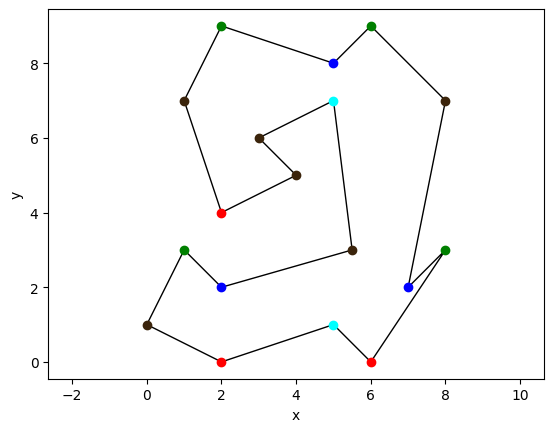

In [23]:
draw_polygon_colors(polygon_example_2,polygon_example_colors)

In [24]:
#poczatkowy - 0
#koncowy - 1
#laczacy - 2
#dzielacy - 3
#prawidłowy - 4

def color_vertex(polygon):
    """
    Funkcja dzieli wierzchołki na kategorie i przypisuje wierzchołkom odpowiednie numery: 0 - początkowy, 1 - końcowy, 2 - łączący, 3 - dzielący, 4 - prawdiłowy
    :param polygon: tablica krotek punktów na płaszczyźnie euklidesowej podanych przeciwnie do ruchu wskazówek zegara - nasz wielokąt
    :return: tablica o długości n, gdzie n = len(polygon), zawierająca cyfry z przedziału 0 - 4, gdzie T[i] odpowiada kategorii i-tego wierzchołka.
    """
    n = len(polygon)
    colors = [0 for _ in range(n)]
    
    for i in range(n):
        current = polygon[i]
        left = polygon[(i + 1) % n]
        right = polygon[(i - 1) % n]

        if current[1] > left[1] and current[1] > right[1] and compare(right, current, left) > 0:
            colors[i] = 0   #poczatkowy
        elif current[1] < left[1] and current[1] < right[1] and compare(right, current, left) < 0:
            colors[i] = 2   #łaczący
        elif current[1] < left[1] and current[1] < right[1] and compare(right, current, left) > 0:
            colors[i] = 1   #końcowy
        elif current[1] > left[1] and current[1] > right[1] and compare(right, current, left) < 0:
            colors[i] = 3   #dzielacy
        else:
            colors[i] = 4   #prawidłowy

    return colors


Przeprowadź test poprawności powyższej funkcji. 

In [25]:
Test().runtest(2, color_vertex)

Lab 3, task 2:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
	Test 4: Passed
	Test 5: Passed
	Test 6: Passed
	Test 7: Passed
	Test 8: Passed
	Test 9: Passed
	Test 10: Passed
Result: 10/10
Time: 0.005s


Zwizualizuj swój wielokąt z pokolorowanymi według kategorii wierzchołkami.

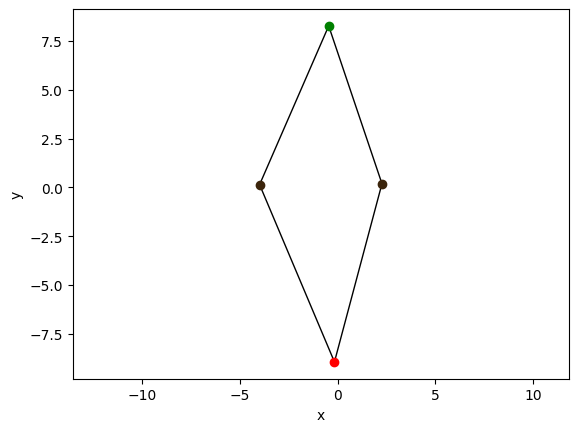

In [26]:
colors = color_vertex(polygon)
draw_polygon_colors(polygon,colors)

***

# Triangulacja wielokąta monotonicznego

Triangulacja wielokąta monotonicznego to proces podziału wielokąta monotonicznego na trójkąty poprzez dodawanie przekątnych (linii łączących wierzchołki), które nie przecinają się wewnętrznie.

### Przykładowy wielokąt podzielony na trójkąty.

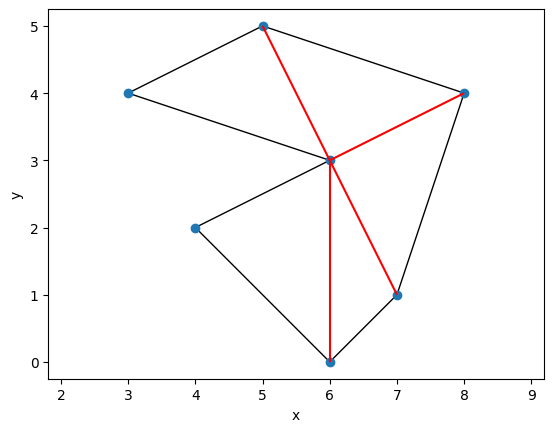

In [27]:
draw_triangulation(polygon_example_1, polygon_example_tri)

<span style="color:red">Ćw.</span> Uzupełnij funkcję ```triangulation```. Wykorzystaj algorytm opisany na wykładzie.

In [28]:
#funkcja sortuje punkty mergesortem malejaco względem współrzędnej y, operujac na dwóch łańcuch left i right, zwraca posortowana liste 
#i tablice chain informujaca, w którym łancuchu znajduja sie kolejne elementy

def sort_monotonically(polygon):
    left, right = partition_into_chains(polygon)
    n, r_length, l_length = len(polygon), len(right), len(left)
    result = [0 for _ in range(n)]
    chain = [0 for _ in range(n)]
    i = j = k = 0
    
    while i < l_length and j < r_length:
        if left[i][1] > right[j][1]:
            result[k] = left[i]
            chain[k] = 0
            i += 1
        else:
            result[k] = right[j]
            chain[k] = 1
            j+= 1
        k+=1
    
    while i < l_length:
        result[k] = left[i]
        chain[k] = 0
        i += 1
        k += 1
    while j < r_length:
        result[k] = right[j]
        chain[k] = 1
        j += 1
        k+=1
    
    return result, chain

In [31]:
#funkcja sprawdza czy dwa punkty sa sasiadujace

def are_adjacent(p1, p2, n):
    return (p1 - p2) % n == 1 or (p2 - p1) % n == 1

In [32]:
#funkcja sprawdza czy trójkat abc nalezy do wnętrza wielokata

def in_polygon(sorted_polygon, top_index, popped_index, current_index, chain):
    #jeśli punkty znajduja się na łancuchu prawym, skręt powinien być w prawo, jeśli na lewym - w lewo (patrzac z perspektywy punktu top_index)
    direction = -1 if chain[popped_index] == 1 else 1
    orient = compare(sorted_polygon[top_index], sorted_polygon[popped_index], sorted_polygon[current_index])
    return orient * direction == 1

In [33]:
def triangulation_diagonals(polygon):
    """
    Funkcja dokonuje triangulacji wielokąta monotonicznego.
    :param polygon: tablica krotek punktów na płaszczyźnie euklidesowej podanych przeciwnie do ruchu wskazówek zegara - nasz wielokąt
    :return: tablica krotek dodawanych po kolei przekątnych np: [(1,5),(2,3)], oznacza, że triangulacja polega na dodaniu przekątnej pomiędzy wierzchołki o indeksach 1 i 5 oraz 2 i 3
    """
    n = len(polygon)
    if n <= 2: return []
    sorted_polygon, chain = sort_monotonically(polygon)
    index_map = {p:i for i,p in enumerate(polygon)}
    diagonals = []
    stack = [0,1]

    #dodajac do stosu i wewnatarz pętli operujemy indeksami z sorted_polygon
    for current_index in range(2, n):
        top_index = stack[-1]

        #top stosu i current nie sa w tym samym łańcuchu
        if chain[top_index] != chain[current_index]:
            #możemy połaczyc current z wszystkimi punktami na stosie
            while len(stack) > 0:
                popped_index = stack.pop()                 
                if not are_adjacent(index_map[sorted_polygon[popped_index]], index_map[sorted_polygon[current_index]], n):
                    diagonals.append((index_map[sorted_polygon[popped_index]], index_map[sorted_polygon[current_index]]))

            stack.append(current_index - 1)
            stack.append(current_index)

        else:
            popped_index = stack.pop()
            top_index = stack[-1]
            #łaczymy w trójkaty punkty na stosie, jeśli sa wewnatrz wielokata
            while in_polygon(sorted_polygon, top_index, popped_index, current_index, chain):
                if not are_adjacent(index_map[sorted_polygon[top_index]], index_map[sorted_polygon[current_index]], n):
                    diagonals.append((index_map[sorted_polygon[top_index]], index_map[sorted_polygon[current_index]]))
                popped_index = stack.pop()
                if len(stack) == 0: break
                top_index = stack[-1]
            stack.append(popped_index)
            stack.append(current_index)

    return diagonals


In [34]:
#funkcja zwraca listę krotek z wierzchołkami utworzonych trójkatów

def triangulation_triangles(polygon):
    """
    Funkcja dokonuje triangulacji wielokąta monotonicznego.
    :param polygon: tablica krotek punktów na płaszczyźnie euklidesowej podanych przeciwnie do ruchu wskazówek zegara - nasz wielokąt
    :return: tablica krotek dodawanych po kolei przekątnych np: [(1,5),(2,3)], oznacza, że triangulacja polega na dodaniu przekątnej pomiędzy wierzchołki o indeksach 1 i 5 oraz 2 i 3
    """
    n = len(polygon)
    if n <= 2: return []
    sorted_polygon, chain = sort_monotonically(polygon)
    index_map = {p:i for i,p in enumerate(polygon)}
    triangles = []
    stack = [0,1]

    #dodajac do stosu i wewnatarz pętli operujemy indeksami z sorted_polygon
    for current_index in range(2, n):
        top_index = stack[-1]

        #top stosu i current nie sa w tym samym łańcuchu
        if chain[top_index] != chain[current_index]:
            #możemy połaczyc current z wszystkimi punktami na stosie
            while len(stack) > 0:
                popped_index = stack.pop()

                #dodawanie trójkata
                if len(stack) > 0:
                    top_index = stack[-1]
                    t = (index_map[sorted_polygon[current_index]], index_map[sorted_polygon[popped_index]], index_map[sorted_polygon[top_index]])
                    if compare(sorted_polygon[current_index], sorted_polygon[popped_index], sorted_polygon[top_index]) == -1:
                        t = (index_map[sorted_polygon[current_index]], index_map[sorted_polygon[top_index]], index_map[sorted_polygon[popped_index]])
                    triangles.append(t)

            stack.append(current_index - 1)
            stack.append(current_index)

        else:
            popped_index = stack.pop()
            top_index = stack[-1]
            #łaczymy w trójkaty punkty na stosie, jeśli sa wewnatrz wielokata
            while in_polygon(sorted_polygon, top_index, popped_index, current_index, chain):

                #dodawanie trójkata
                t = (index_map[sorted_polygon[top_index]], index_map[sorted_polygon[popped_index]], index_map[sorted_polygon[current_index]])
                if compare(sorted_polygon[top_index], sorted_polygon[popped_index], sorted_polygon[current_index]) == -1:
                    t = (index_map[sorted_polygon[top_index]], index_map[sorted_polygon[current_index]], index_map[sorted_polygon[popped_index]])
                triangles.append(t)

                popped_index = stack.pop()
                if len(stack) == 0: break
                top_index = stack[-1]
            stack.append(popped_index)
            stack.append(current_index)

    return triangles


Przeprowadź testy poprawności powyższej funkcji.


In [35]:
Test().runtest(3, triangulation_diagonals)

Lab 3, task 3:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
	Test 4: Passed
	Test 5: Passed
	Test 6: Passed
	Test 7: Passed
	Test 8: Passed
	Test 9: Passed
	Test 10: Passed
Result: 10/10
Time: 0.004s


Zwizualizuj powstały wielokąt podzielony na trójkąty.

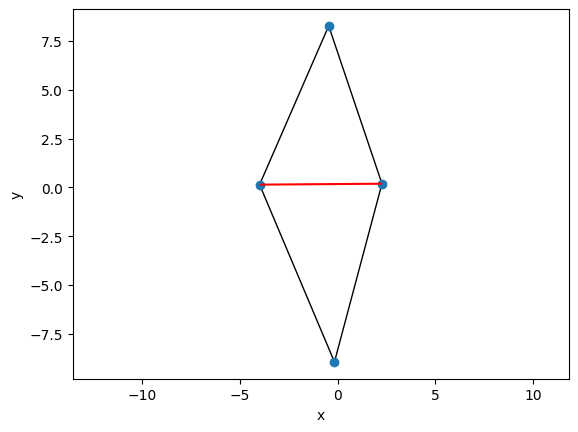

In [36]:
T = [(polygon[i], polygon[j]) for i,j in triangulation_diagonals(polygon)]
draw_triangulation(polygon, T)

In [265]:
Wizualizacja triangulacji


SyntaxError: invalid syntax (3632142338.py, line 1)

In [37]:
def triangulation_gif(polygon):
    n = len(polygon)
    if n <= 2: return []
    sorted_polygon, chain = sort_monotonically(polygon)
    index_map = {t:i for i,t in enumerate(polygon)}
    
    vis = Visualizer()
    vis.axis_equal()
    vis.add_polygon(polygon, fill=False)
    vis.add_point(polygon)
    
    diagonals = []
    stack = [0,1]
    vis.add_point([sorted_polygon[stack[-1]], sorted_polygon[stack[-2]]], color="red")
    for current_index in range(2, n):
        top_index = stack[-1]

        #top stosu i current nie sa w tym samym łańcuchu
        if chain[top_index] != chain[current_index]:
            #możemy połaczyc current z wszystkimi punktami na stosie
            while len(stack) > 0:
                popped_index = stack.pop()
                vis.add_point(sorted_polygon[popped_index], color="brown")
                if not are_adjacent(index_map[sorted_polygon[popped_index]], index_map[sorted_polygon[current_index]], n):
                    diagonals.append((index_map[sorted_polygon[popped_index]], index_map[sorted_polygon[current_index]]))
                    vis.add_line_segment([sorted_polygon[popped_index], sorted_polygon[current_index]], color="red")

            stack.append(current_index - 1)
            stack.append(current_index)
            vis.add_point([sorted_polygon[current_index], sorted_polygon[current_index - 1]], color="red")

        else:
            popped_index = stack.pop()
            vis.add_point(sorted_polygon[popped_index], color="brown")
            top_index = stack[-1]
            #łaczymy w trójkaty punkty na stosie, jeśli sa wewnatrz wielokata
            while in_polygon(sorted_polygon, top_index, popped_index, current_index, chain):
                if not are_adjacent(index_map[sorted_polygon[top_index]], index_map[sorted_polygon[current_index]], n):
                    diagonals.append((index_map[sorted_polygon[top_index]], index_map[sorted_polygon[current_index]]))
                    vis.add_line_segment([sorted_polygon[top_index], sorted_polygon[current_index]], color="red")
                    
                popped_index = stack.pop()
                vis.add_point(sorted_polygon[popped_index], color="brown")
                
                if len(stack) == 0: break
                top_index = stack[-1]
                
            stack.append(popped_index)
            stack.append(current_index)
            vis.add_point([sorted_polygon[popped_index],sorted_polygon[current_index]], color="red")

    return diagonals, vis

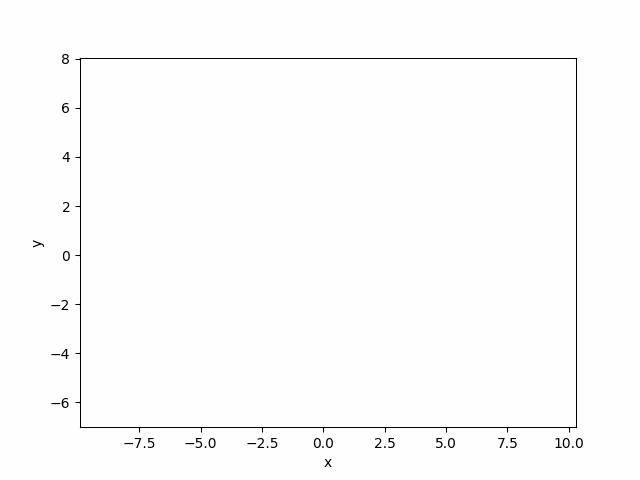

In [267]:
_, vis = triangulation_gif(polygon)
vis.show_gif(interval=500)

In [167]:
Wielokaty


NameError: name 'Wielokaty' is not defined

is monotonic: True
diagonals: [(3, 1)]
triangles: [(1, 3, 0), (3, 1, 2)]


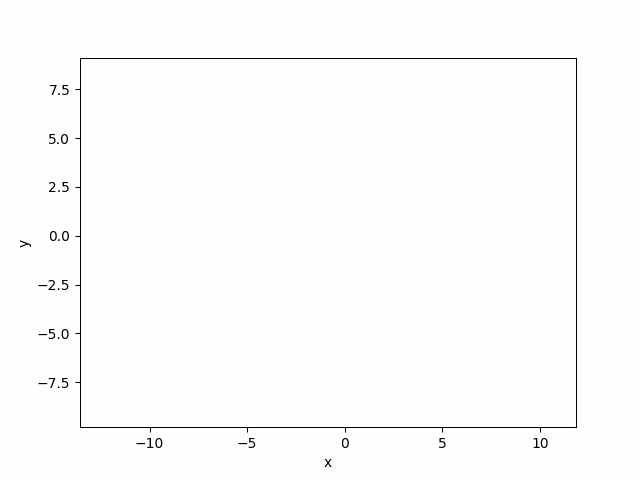

In [38]:
polygonA = load_vertices('A')
save_polygon(polygonA, 'A')
print(f'is monotonic: {is_y_monotonic(polygonA)}')

colors = color_vertex(polygonA)
save_polygon_colors(polygonA, colors, 'A')

T = triangulation_diagonals(polygonA)
t = triangulation_triangles(polygonA)
save_triangulation(polygonA, [(polygon[x], polygon[y]) for x, y in T], 'A')
print(f'diagonals: {T}')
print(f'triangles: {t}')

_, vis = triangulation_gif(polygonA)
vis.save_gif(os.path.join('data', 'A', 'gif_A'), interval=500)
vis.show_gif(interval=500)

is monotonic: True
diagonals: [(10, 1), (1, 9), (9, 2), (2, 8), (8, 3), (3, 7), (7, 4), (4, 6)]
triangles: [(1, 10, 0), (9, 10, 1), (2, 9, 1), (8, 9, 2), (3, 8, 2), (7, 8, 3), (4, 7, 3), (6, 7, 4), (5, 6, 4)]


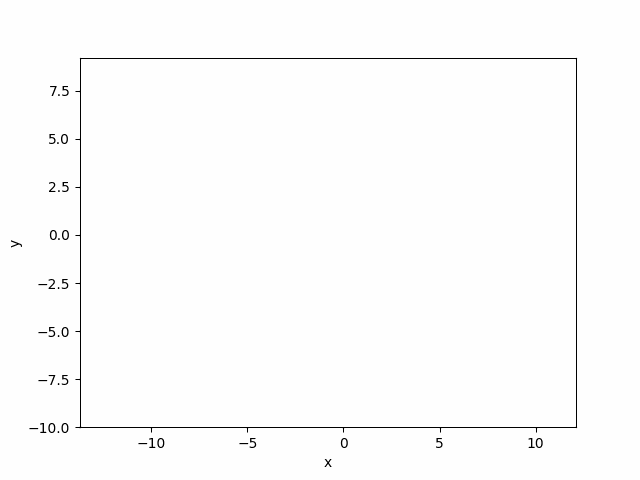

In [395]:
polygonB = load_vertices('B')
save_polygon(polygonB, 'B')
print(f'is monotonic: {is_y_monotonic(polygonB)}')

colors = color_vertex(polygonB)
save_polygon_colors(polygonB, colors, 'B')

T = triangulation_diagonals(polygonB)
t = triangulation_triangles(polygonB)
save_triangulation(polygonB, [(polygonB[x], polygonB[y]) for x, y in T], 'B')
print(f'diagonals: {T}')
print(f'triangles: {t}')

_, vis = triangulation_gif(polygonB)
vis.save_gif(os.path.join('data', 'B', 'gif_B'), interval=500)
vis.show_gif(interval=500)

is monotonic: True
diagonals: [(0, 7), (7, 5), (0, 5), (5, 3), (0, 3), (3, 1)]
triangles: [(0, 7, 8), (7, 5, 6), (0, 5, 7), (5, 3, 4), (0, 3, 5), (1, 2, 3), (1, 3, 0)]


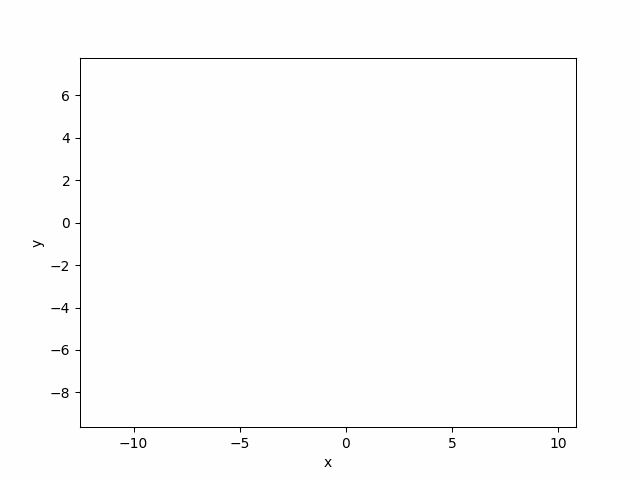

In [396]:
polygonC = load_vertices('C')
save_polygon(polygonC, 'C')
print(f'is monotonic: {is_y_monotonic(polygonC)}')

colors = color_vertex(polygonC)
save_polygon_colors(polygonC, colors, 'C')

T = triangulation_diagonals(polygonC)
t = triangulation_triangles(polygonC)
save_triangulation(polygonC, [(polygonC[x], polygonC[y]) for x, y in T], 'C')
print(f'diagonals: {T}')
print(f'triangles: {t}')

_, vis = triangulation_gif(polygonC)
vis.save_gif(os.path.join('data', 'C', 'gif_C'), interval=500)
vis.show_gif(interval=500)

is monotonic: True
diagonals: [(8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3)]
triangles: [(1, 8, 9), (1, 9, 10), (1, 10, 11), (1, 11, 12), (1, 12, 0), (7, 8, 1), (1, 6, 7), (1, 5, 6), (1, 4, 5), (1, 3, 4), (2, 3, 1)]


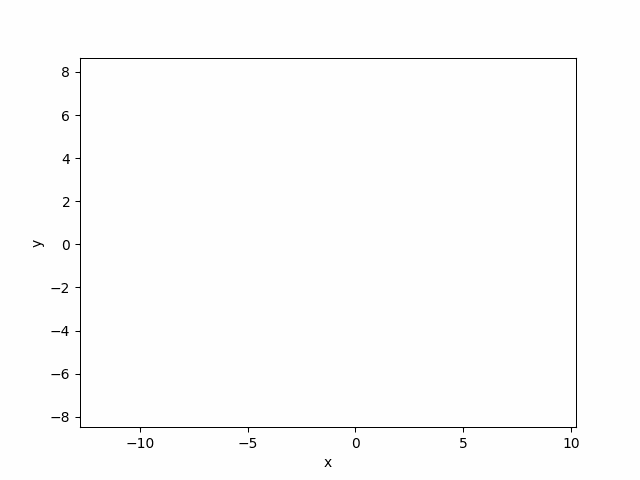

In [397]:
polygonD = load_vertices('D')
save_polygon(polygonD, 'D')
print(f'is monotonic: {is_y_monotonic(polygonD)}')

colors = color_vertex(polygonD)
save_polygon_colors(polygonD, colors, 'D')

T = triangulation_diagonals(polygonD)
t = triangulation_triangles(polygonD)
save_triangulation(polygonD, [(polygonD[x], polygonD[y]) for x, y in T], 'D')
print(f'diagonals: {T}')
print(f'triangles: {t}')

_, vis = triangulation_gif(polygonD)
vis.save_gif(os.path.join('data', 'D', 'gif_D'), interval=500)
vis.show_gif(interval=500)

is monotonic: False
diagonals: [(31, 1), (1, 30), (29, 2), (30, 2), (2, 28), (27, 3), (28, 3), (5, 7), (5, 8), (4, 8), (4, 9), (9, 26), (4, 26), (3, 26), (24, 10), (25, 10), (26, 10), (10, 23), (23, 11), (11, 22), (22, 12), (12, 21), (12, 20), (12, 19), (17, 13), (18, 13), (19, 13), (13, 15), (13, 16)]
triangles: [(31, 0, 1), (30, 1, 31), (2, 30, 29), (2, 1, 30), (28, 2, 29), (3, 28, 27), (3, 2, 28), (5, 6, 7), (5, 7, 8), (4, 5, 8), (4, 8, 9), (26, 4, 9), (26, 3, 4), (26, 3, 27), (10, 25, 24), (10, 26, 25), (10, 9, 26), (23, 10, 24), (11, 10, 23), (22, 11, 23), (12, 11, 22), (21, 12, 22), (12, 20, 21), (12, 19, 20), (13, 18, 17), (13, 19, 18), (13, 12, 19), (13, 14, 15), (13, 15, 16)]


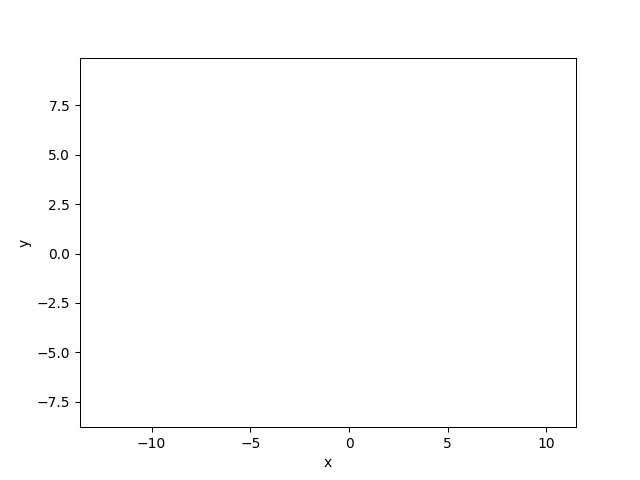

In [398]:
polygonE = load_vertices('E')
save_polygon(polygonE, 'E')
print(f'is monotonic: {is_y_monotonic(polygonE)}')

colors = color_vertex(polygonE)
save_polygon_colors(polygonE, colors, 'E')

T = triangulation_diagonals(polygonE)
t = triangulation_triangles(polygonE)
save_triangulation(polygonE, [(polygonE[x], polygonE[y]) for x, y in T], 'E')
print(f'diagonals: {T}')
print(f'triangles: {t}')

_, vis = triangulation_gif(polygonE)
vis.save_gif(os.path.join('data', 'E', 'gif_E'), interval=500)
vis.show_gif(interval=500)